# Movie Genre Associations: Recommendation System Using Market Basket Analysis

## Objective

- Analyze users’ movie-watching patterns to discover frequently co-watched genres.

- Build a simple recommendation system using association rules.


## Dataset

The dataset consists of 9,125 movie records and 3 attributes:

| Column Name | Description                                                              |
| ----------- | -------------------------------------------------------------------------|
| **movieId** | A unique identifier assigned to each movie                               |
| **title**   | The name of the movie along with its release year                        |
| **genres**  | A list of genres associated with the movie                               |


## Importing Packages

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori,association_rules
import warnings
warnings.filterwarnings('ignore')

In [2]:
movies = pd.read_csv(r'D:\ds ai ml\DS@AI\00-portfolio-projects\Movie Genre Association\movies.csv')
movies

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
...,...,...,...
9120,162672,Mohenjo Daro (2016),Adventure|Drama|Romance
9121,163056,Shin Godzilla (2016),Action|Adventure|Fantasy|Sci-Fi
9122,163949,The Beatles: Eight Days a Week - The Touring Y...,Documentary
9123,164977,The Gay Desperado (1936),Comedy


## Data Preprocessing

In [3]:
movies['genres_split']  = movies['genres'].str.split('|')  # removing | and adding the genres in another column


In [4]:
movies

,movieId,title,genres,genres_split
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,"[Adventure, Animation, Children, Comedy, Fantasy]"
1,2,Jumanji (1995),Adventure|Children|Fantasy,"[Adventure, Children, Fantasy]"
2,3,Grumpier Old Men (1995),Comedy|Romance,"[Comedy, Romance]"
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,"[Comedy, Drama, Romance]"
4,5,Father of the Bride Part II (1995),Comedy,[Comedy]
...,...,...,...,...
9120,162672,Mohenjo Daro (2016),Adventure|Drama|Romance,"[Adventure, Drama, Romance]"
9121,163056,Shin Godzilla (2016),Action|Adventure|Fantasy|Sci-Fi,"[Action, Adventure, Fantasy, Sci-Fi]"
9122,163949,The Beatles: Eight Days a Week - The Touring Y...,Documentary,[Documentary]
9123,164977,The Gay Desperado (1936),Comedy,[Comedy]


In [5]:
transactions = movies['genres_split'].tolist()  #should be passed in list


### Encoding

In [6]:
from mlxtend.preprocessing import TransactionEncoder
te= TransactionEncoder()

te_array = te.fit(transactions).transform(transactions)
movies_encoded = pd.DataFrame(te_array,columns=te.columns_)
movies_encoded = movies_encoded.replace({True:1,False:0})

movies_oh = pd.concat([movies.drop(columns=['genres', 'genres_split']), movies_encoded], axis=1)


In [7]:
movies_oh

,movieId,title,(no genres listed),Action,Adventure,Animation,Children,Comedy,Crime,Documentary,...,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story (1995),0,0,1,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,Jumanji (1995),0,0,1,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3,Grumpier Old Men (1995),0,0,0,0,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0
3,4,Waiting to Exhale (1995),0,0,0,0,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0
4,5,Father of the Bride Part II (1995),0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9120,162672,Mohenjo Daro (2016),0,0,1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
9121,163056,Shin Godzilla (2016),0,1,1,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
9122,163949,The Beatles: Eight Days a Week - The Touring Y...,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
9123,164977,The Gay Desperado (1936),0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


In [8]:
movies_oh.set_index(['movieId','title'],inplace=True)
movies_oh

,,(no genres listed),Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
movieId,title,,,,,,,,,,,,,,,,,,,,
1,Toy Story (1995),0,0,1,1,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0
2,Jumanji (1995),0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
3,Grumpier Old Men (1995),0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0
4,Waiting to Exhale (1995),0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0
5,Father of the Bride Part II (1995),0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
162672,Mohenjo Daro (2016),0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0
163056,Shin Godzilla (2016),0,1,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0
163949,The Beatles: Eight Days a Week - The Touring Years (2016),0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0


### Splitting Data into Training and Test Sets

In [9]:
from sklearn.model_selection import train_test_split
train, test = train_test_split(movies_oh, test_size=0.3, random_state=42)

## Applying Market Basket analysis

### Rules for Train data

In [10]:
frequent_itemsets_movies = apriori(train,use_colnames=True,min_support=0.01)
frequent_itemsets_movies

,support,itemsets
0,0.170189,(Action)
1,0.121810,(Adventure)
2,0.047127,(Animation)
3,0.064036,(Children)
4,0.360263,(Comedy)
...,...,...
87,0.037107,"(Drama, Comedy, Romance)"
88,0.011743,"(Drama, Mystery, Crime)"
89,0.033506,"(Drama, Crime, Thriller)"
90,0.013465,"(Mystery, Crime, Thriller)"


In [11]:
rules_train =  association_rules(frequent_itemsets_movies, metric='lift', min_threshold=1)

In [12]:
rules_train.shape

(178, 14)

In [13]:
rules_train[(rules_train.lift>2)].sort_values(by=['lift','confidence'], ascending=[False,False])

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
122,"(Children, Adventure)",(Animation),0.028809,0.047127,0.013935,0.483696,10.263668,1.0,0.012577,1.845565,0.929342,0.224747,0.458160,0.389688
123,(Animation),"(Children, Adventure)",0.047127,0.028809,0.013935,0.295681,10.263668,1.0,0.012577,1.378909,0.947208,0.224747,0.274789,0.389688
121,"(Animation, Adventure)",(Children),0.021293,0.064036,0.013935,0.654412,10.219384,1.0,0.012571,2.708320,0.921774,0.195175,0.630767,0.436008
124,(Children),"(Animation, Adventure)",0.064036,0.021293,0.013935,0.217604,10.219384,1.0,0.012571,1.250910,0.963869,0.195175,0.200582,0.436008
145,"(Animation, Comedy)",(Children),0.021293,0.064036,0.013621,0.639706,9.989735,1.0,0.012258,2.597777,0.919476,0.189956,0.615055,0.426210
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
153,(Romance),"(Drama, Comedy)",0.169563,0.103961,0.037107,0.218837,2.104984,1.0,0.019479,1.147057,0.632121,0.156954,0.128204,0.287882
116,"(Action, Sci-Fi)",(Thriller),0.040081,0.190543,0.015970,0.398437,2.091060,1.0,0.008333,1.345590,0.543560,0.074398,0.256832,0.241125
117,(Thriller),"(Action, Sci-Fi)",0.190543,0.040081,0.015970,0.083813,2.091060,1.0,0.008333,1.047732,0.644597,0.074398,0.045557,0.241125
12,(War),(Action),0.040238,0.170189,0.013935,0.346304,2.034812,1.0,0.007086,1.269413,0.529875,0.070916,0.212234,0.214090


### Validating with test data
Evaluation metrics: Support, Confidence, Lift

In [14]:
def validate_rule(rule, df): 
    # Extract antecedent --> consequent for each rule from train data
    antecedent = list(rule['antecedents'])
    consequent = list(rule['consequents'])
    
    # Avoid empty antecedent or consequent
    if len(antecedent) == 0 or len(consequent) == 0:
        return pd.Series([0, 0, 0], index=['support_test', 'confidence_test', 'lift_test'])

    # For the antecedent --> consequent in each rule, metrics calculated for test set for respective antecedent --> consequent
    # Support in test set
    support = df[antecedent + consequent].all(axis=1).mean()    # only when both antedent and consequen appear together
    
    # Confidence in test set
    antecedent_support = df[antecedent].all(axis=1).mean()
    confidence = support / antecedent_support if antecedent_support > 0 else 0
    
    # Lift in test set
    consequent_support = df[consequent].all(axis=1).mean()
    lift = confidence / consequent_support if consequent_support > 0 else 0
    
    return pd.Series([support, confidence, lift], index=['support_test', 'confidence_test', 'lift_test'])

In [15]:
# Apply validation
rules_test_metrics = rules_train.apply(validate_rule, axis=1, df=test)
rules_validated = pd.concat([rules_train, rules_test_metrics], axis=1)


In [16]:
# initial threshold
support_threshold = 0.05
confidence_threshold = 0.5
lift_threshold = 1.0

filtered_rules = rules_validated[
    (rules_validated['support_test'] >= support_threshold) &
    (rules_validated['confidence_test'] >= confidence_threshold) &
    (rules_validated['lift_test'] >= lift_threshold)
]

print("Validated Rules on Test Set:")
print(filtered_rules[['antecedents', 'consequents','support','confidence', 'lift','support_test','confidence_test','lift_test']])


Validated Rules on Test Set:
    antecedents consequents   support  confidence      lift  support_test  \
0   (Adventure)    (Action)  0.056678    0.465296  2.733986      0.062089   
41      (Crime)     (Drama)  0.069829    0.563131  1.170807      0.062454   
49    (Romance)     (Drama)  0.099890    0.589104  1.224808      0.104456   

    confidence_test  lift_test  
0          0.501475   2.997900  
41         0.555195   1.175656  
49         0.619048   1.310868  


#### Validation of Association Rules on Test Set:
- Association rules generated from the training data were validated on unseen test data by recalculating support, confidence and lift.
- Rules with test metrics above the thresholds (support ≥ 0.05, confidence ≥ 0.5, lift ≥ 1.0) were considered initially 
- Only a few rules, such as Adventure → Action, Crime → Drama, and Romance → Drama, passed these thresholds.

- Since many movies have 2–3 genres, so the probability of any specific combination is low. Using thresholds like support ≥ 0.05 removes most rare but potentially interesting combinations. Confidence ≥ 0.5 filters out rules where the antecedent is rare.

- Lowering the thresholds could capture more patterns but may also include weaker rules


In [17]:
# Adjusting thresholds
support_threshold = 0.01
confidence_threshold = 0.5
lift_threshold = 1.2

filtered_rules = rules_validated[
    (rules_validated['support_test'] >= support_threshold) &
    (rules_validated['confidence_test'] >= confidence_threshold) &
    (rules_validated['lift_test'] >= lift_threshold)
]

print("Validated Rules on Test Set:")
print(filtered_rules[['antecedents', 'consequents','support','confidence', 'lift','support_test','confidence_test','lift_test']])

Validated Rules on Test Set:
                antecedents  consequents   support  confidence       lift  \
0               (Adventure)     (Action)  0.056678    0.465296   2.733986   
14              (Animation)  (Adventure)  0.021293    0.451827   3.709281   
22              (Animation)   (Children)  0.026147    0.554817   8.664103   
49                (Romance)      (Drama)  0.099890    0.589104   1.224808   
50                    (War)      (Drama)  0.030374    0.754864   1.569439   
60                (Mystery)   (Thriller)  0.035541    0.608579   3.193915   
73        (Fantasy, Action)  (Adventure)  0.010647    0.635514   5.217260   
79      (Adventure, Sci-Fi)     (Action)  0.017066    0.622857   3.659787   
85    (Adventure, Thriller)     (Action)  0.016440    0.766423   4.503354   
98          (Crime, Action)   (Thriller)  0.022233    0.554687   2.911084   
115      (Sci-Fi, Thriller)     (Action)  0.015970    0.545455   3.204985   
120   (Animation, Children)  (Adventure)  0.013

### Validation of Association Rules on Test set(Adjusted thresholds)

- Lowered the support threshold to 0.01 and lift threshold to 1.2, capturing more rules, including rare combinations
- High lift (some >10) indicates strong associations between antecedent and consequent genres
- Support is low for rare combinations
- Rules provide richer basis for genre-based recommendations

### Applying on full data set with validated thresholds

In [18]:
# Adjusting thresholds
# support_threshold = 0.01
# confidence_threshold = 0.5
# lift_threshold = 1.2

frequent_movies = apriori(movies_oh,use_colnames=True,min_support=0.01)


rules =  association_rules(frequent_movies, metric='confidence', min_threshold = 0.5) 


In [19]:
rules = rules[rules['lift']>2].sort_values(by=['lift','confidence'], ascending=[False,False])

In [20]:
print(rules[['antecedents','consequents','support','confidence','lift']])

               antecedents  consequents   support  confidence       lift
16   (Children, Adventure)  (Animation)  0.014685    0.501873  10.245163
15  (Animation, Adventure)   (Children)  0.014685    0.629108   9.846673
19     (Animation, Comedy)   (Children)  0.013370    0.625641   9.792409
1              (Animation)   (Children)  0.027068    0.552573   8.648758
9        (Fantasy, Action)  (Adventure)  0.012493    0.674556   5.510587
18     (Children, Fantasy)  (Adventure)  0.011726    0.581522   4.750569
11   (Adventure, Thriller)     (Action)  0.016000    0.784946   4.636009
14   (Animation, Children)  (Adventure)  0.014685    0.542510   4.431875
17     (Animation, Comedy)  (Adventure)  0.010959    0.512821   4.189335
10     (Adventure, Sci-Fi)     (Action)  0.017863    0.644269   3.805147
22        (Mystery, Crime)   (Thriller)  0.012493    0.682635   3.602685
0                   (IMAX)     (Action)  0.010082    0.601307   3.551410
13      (Sci-Fi, Thriller)     (Action)  0.015781  

### Visualising Top 5 rules 

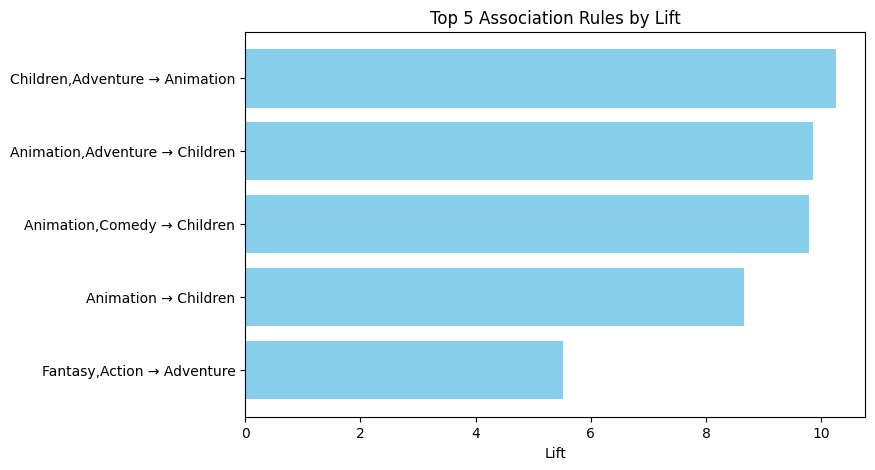

In [21]:
import matplotlib.pyplot as plt

# Assuming 'rules' is a DataFrame with 'antecedents', 'consequents', 'lift'
rules['rule'] = rules['antecedents'].apply(lambda x: ','.join(list(x))) + " → " + rules['consequents'].apply(lambda x: ','.join(list(x)))
top_k = rules.sort_values('lift', ascending=False).head(5)

plt.figure(figsize=(8,5))
plt.barh(top_k['rule'], top_k['lift'], color='skyblue')
plt.xlabel('Lift')
plt.title('Top 5 Association Rules by Lift')
plt.gca().invert_yaxis()  # largest on top
plt.show()


### Heat map of lift between Antecedents and Consequents

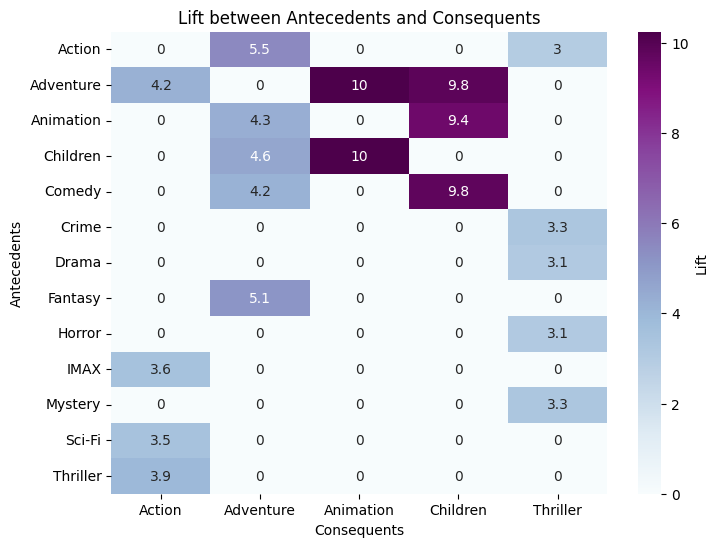

In [22]:

# Convert frozensets to lists directly in a DataFrame
df = rules[['antecedents', 'consequents', 'lift']].copy()
df['antecedents'] = df['antecedents'].apply(list)
df['consequents'] = df['consequents'].apply(list)

# Explode antecedents and consequents
df = df.explode('antecedents').explode('consequents')

# Create lift matrix using pivot table
lift_matrix = df.pivot_table(
    index='antecedents',
    columns='consequents',
    values='lift',
    fill_value=0
)

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(lift_matrix, annot=True, cmap="BuPu", cbar_kws={'label': 'Lift'})
plt.title("Lift between Antecedents and Consequents")
plt.xlabel("Consequents")
plt.ylabel("Antecedents")
plt.show()


## Recommendation of genres

In [23]:
def recommend_genre(user_genre, rules_df, top_n=3): 
    recom = rules_df[rules_df['antecedents'].apply(lambda x: user_genre in x)]
    recom = recom.sort_values(by='lift', ascending=False) 
    return recom['consequents'].apply(list).explode().unique()[:top_n]

This function implements a rule-based recommendation system using association rule mining. Given a user’s preferred genre, it identifies relevant rules, ranks them by lift, and recommends the most strongly associated genres.

In [24]:
recommend_genre(('Animation') ,rules)

array(['Children', 'Adventure'], dtype=object)

## Conclusion

- Market Basket Analysis was applied to identify frequent genre associations from movie-watching patterns.

- Transaction Data was preprocessed to split movie genres, enabling the identification of co-watched genres.

- The Apriori algorithm was used to discover association rules, filtered by optimal thresholds for support, confidence, and lift.

- Evaluation metrics (Support, Confidence, Lift) were used to validate the rules and select the most relevant ones.

- A recommendation function was developed to suggest genres based on previously watched genres.

- Visualization techniques, including heatmaps, were used to display the strength of associations.

- The system effectively predicts genre relationships and provides genre-based recommendations, with potential for further refinement using user feedback.